<!--<badge>--><a href="https://colab.research.google.com/github/JoeChen322/Fintech/blob/main/recommend-system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import gdown
import tqdm

%config InlineBackend.figure_format = 'retina'

In [2]:
url = "https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX"
file_path = "Dataset2_Needs.xls"
gdown.download(url, file_path, quiet=False)
needs_df = pd.read_excel(file_path, sheet_name="Needs")
products_df = pd.read_excel(file_path, sheet_name="Products")
metadata_df = pd.read_excel(file_path, sheet_name="Metadata")

print("Needs shape:", needs_df.shape)
print("Products shape:", products_df.shape)
print("Metadata shape:", metadata_df.shape)

Downloading...
From: https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX
To: /Users/pengrao/Workspace/Fintech/Dataset2_Needs.xls
100%|██████████| 428k/428k [00:00<00:00, 13.9MB/s]


Needs shape: (5000, 10)
Products shape: (11, 3)
Metadata shape: (29, 2)


In [3]:
needs_df.head()

,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
0,1,60,0,2,0.228685,0.233355,68.181525,53.260067,0,1
1,2,78,0,2,0.358916,0.170911,21.807595,135.550048,1,0
2,3,33,1,2,0.317515,0.249703,23.252747,66.303678,0,1
3,4,69,1,4,0.767685,0.654597,166.189034,404.997689,1,1
4,5,58,0,3,0.429719,0.349039,21.186723,58.911930,0,0


## Target distribution

Quick sanity-check of label balance for both targets (and their joint distribution).


,IncomeInvestment,AccumulationInvestment
class,,
0,3082,2434
1,1918,2566


,IncomeInvestment,AccumulationInvestment
class,,
0,0.6164,0.4868
1,0.3836,0.5132


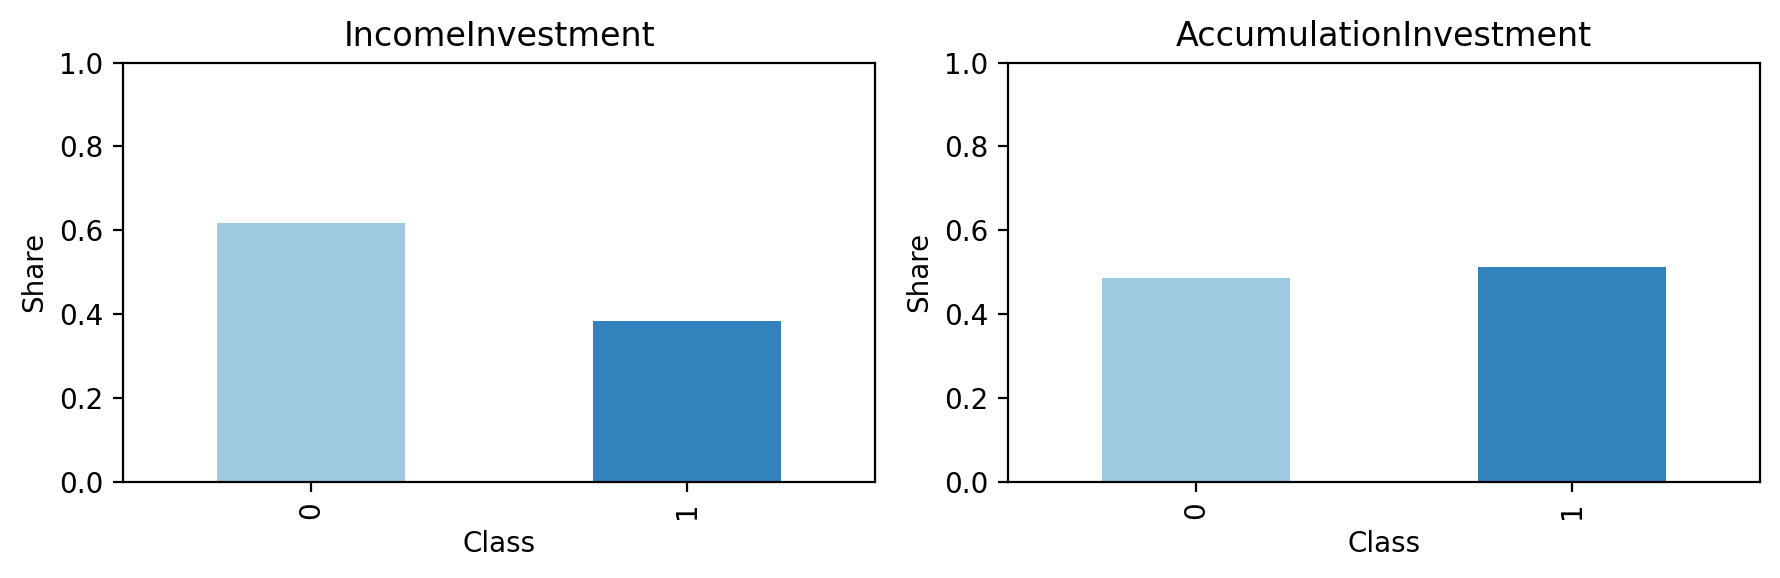

AccumulationInvestment,0,1
IncomeInvestment,,
0,1514,1568
1,920,998


AccumulationInvestment,0,1
IncomeInvestment,,
0,0.3028,0.3136
1,0.1840,0.1996


In [4]:
from IPython.display import display

targets = ["IncomeInvestment", "AccumulationInvestment"]

summary = (
    pd.DataFrame({t: needs_df[t].value_counts().sort_index() for t in targets})
    .fillna(0)
    .astype(int)
)
summary.index.name = "class"
display(summary)

shares = pd.DataFrame(
    {t: needs_df[t].value_counts(normalize=True).sort_index() for t in targets}
).fillna(0.0)
shares.index.name = "class"
display(shares)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, t in zip(axes, targets):
    needs_df[t].value_counts(normalize=True).sort_index().plot(
        kind="bar", ax=ax, color=["#9ecae1", "#3182bd"]
    )
    ax.set_title(t)
    ax.set_xlabel("Class")
    ax.set_ylabel("Share")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

joint_counts = pd.crosstab(needs_df[targets[0]], needs_df[targets[1]])
joint_counts.index.name = targets[0]
joint_counts.columns.name = targets[1]
display(joint_counts)

joint_share = pd.crosstab(needs_df[targets[0]], needs_df[targets[1]], normalize="all")
joint_share.index.name = targets[0]
joint_share.columns.name = targets[1]
display(joint_share)


In [5]:
products_df.head()

,IDProduct,Type,Risk
0,1,1,0.55
1,2,0,0.30
2,3,0,0.12
3,4,0,0.44
4,5,1,0.41


In [6]:
metadata_df.head()

,Metadata,Unnamed: 1
0,Clients,NaN
1,ID,Numerical ID
2,Age,"Age, in years"
3,Gender,"Gender (Female = 1, Male = 0)"
4,FamilyMembers,Number of components


## Data processing

This cell cleans the tabular data, builds the engineered features, and prepares the train/test split used by the recommendation models.


In [7]:
needs_df = needs_df.copy()
products_df = products_df.copy()
metadata_df = metadata_df.copy()

In [8]:
needs_df

,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
0,1,60,0,2,0.228685,0.233355,68.181525,53.260067,0,1
1,2,78,0,2,0.358916,0.170911,21.807595,135.550048,1,0
2,3,33,1,2,0.317515,0.249703,23.252747,66.303678,0,1
3,4,69,1,4,0.767685,0.654597,166.189034,404.997689,1,1
4,5,58,0,3,0.429719,0.349039,21.186723,58.911930,0,0
...,...,...,...,...,...,...,...,...,...,...
4995,4996,60,1,3,0.609411,0.588353,10.253281,57.368572,0,0
4996,4997,65,1,3,0.523238,0.343272,104.155427,156.824602,1,1
4997,4998,56,1,3,0.433826,0.402771,56.097301,63.283774,0,1
4998,4999,51,1,3,0.559793,0.431419,62.523298,95.357528,0,0


In [9]:
needs_df.columns

Index(['ID', 'Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
       'RiskPropensity', 'Income', 'Wealth', 'IncomeInvestment',
       'AccumulationInvestment'],
      dtype='str')

In [10]:
if "ID" in needs_df.columns:
    needs_df = needs_df.drop(columns=["ID"])

needs_df["Income_log"] = np.log1p(needs_df["Income"].clip(lower=0))
needs_df["Wealth_log"] = np.log1p(needs_df["Wealth"].clip(lower=0))
needs_df["Income_Wealth_Ratio"] = needs_df["Income"] / needs_df["Wealth"].replace(
    0, np.nan
)
needs_df["Income_Wealth_Ratio"] = needs_df["Income_Wealth_Ratio"].fillna(0)

feature_columns = [
    "Age",
    "Gender",
    "FamilyMembers",
    "FinancialEducation",
    "RiskPropensity",
    "Income_log",
    "Wealth_log",
    "Income_Wealth_Ratio",
]
X_base = needs_df[feature_columns].copy()
scaler = StandardScaler()
X_base = pd.DataFrame(
    scaler.fit_transform(X_base), columns=feature_columns, index=needs_df.index
)
X_engineered = X_base.copy()

# Use ONE split so X/y stay aligned for both targets
X_train, X_test = train_test_split(
    X_base,
    test_size=0.2,
    random_state=42,
    stratify=needs_df["AccumulationInvestment"],
)

y_train_accum = needs_df.loc[X_train.index, "AccumulationInvestment"].astype(int)
y_test_accum = needs_df.loc[X_test.index, "AccumulationInvestment"].astype(int)
y_train_income = needs_df.loc[X_train.index, "IncomeInvestment"].astype(int)
y_test_income = needs_df.loc[X_test.index, "IncomeInvestment"].astype(int)

test_clients = needs_df.loc[X_test.index].copy()

print("Processed features:", X_base.shape)
print("Train set:", X_train.shape)
print("Test set:", X_test.shape)
X_base.head()

Processed features: (5000, 8)
Train set: (4000, 8)
Test set: (1000, 8)


,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income_log,Wealth_log,Income_Wealth_Ratio
0,0.396525,-0.984126,-0.670284,-1.258110,-0.855883,0.433447,-0.205413,0.089764
1,1.900222,-0.984126,-0.670284,-0.397747,-1.269115,-1.004129,0.833019,-0.310416
2,-1.859021,1.016130,-0.670284,-0.671259,-0.747694,-0.924536,0.036981,-0.242549
3,1.148373,1.016130,1.955193,2.302746,1.931786,1.576615,2.059078,-0.221224
4,0.229447,-0.984126,0.642454,0.070007,-0.090315,-1.039885,-0.093922,-0.239356


In [11]:
accumulation_products = products_df[products_df["Type"] == 1].copy()
income_products = products_df[products_df["Type"] == 0].copy()
test_clients = needs_df.loc[X_test.index].copy()


In [12]:
svm_accum = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42,
)
svm_income = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42,
)

In [13]:
svm_accum.fit(X_train, y_train_accum)
accum_pred = pd.Series(svm_accum.predict(X_test).astype(int), index=X_test.index)
print("Accumulation positive predictions:", int(accum_pred.sum()))

svm_income.fit(X_train, y_train_income)
income_pred = pd.Series(svm_income.predict(X_test).astype(int), index=X_test.index)
print("Income positive predictions:", int(income_pred.sum()))

Accumulation positive predictions: 468
Income positive predictions: 333


## Classification metrics (SVC)

Evaluate SVC models on the shared train/test split for both targets.


In [14]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def compute_binary_metrics(y_true, y_pred, y_proba=None):
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    if y_proba is not None:
        out["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        out["pr_auc"] = float(average_precision_score(y_true, y_proba))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    out.update({"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)})
    return out


svc_metrics = {}

accum_proba_test = svm_accum.predict_proba(X_test)[:, 1]
income_proba_test = svm_income.predict_proba(X_test)[:, 1]

svc_metrics["AccumulationInvestment"] = compute_binary_metrics(
    y_test_accum.values, accum_pred.values, accum_proba_test
)
svc_metrics["IncomeInvestment"] = compute_binary_metrics(
    y_test_income.values, income_pred.values, income_proba_test
)

pd.DataFrame(svc_metrics).T.sort_values("f1", ascending=False)

,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
AccumulationInvestment,0.757,0.788462,0.719298,0.752294,0.803727,0.825111,388.0,99.0,144.0,369.0
IncomeInvestment,0.789,0.789790,0.650990,0.713704,0.798770,0.803278,526.0,70.0,141.0,263.0


In [15]:
age_min = needs_df["Age"].min()
age_max = needs_df["Age"].max()
wealth_min = needs_df["Wealth"].min()
wealth_max = needs_df["Wealth"].max()

## Neural network baseline (MLP)

Train a small MLP classifier and compare metrics vs SVC.


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train_mlp_classifier(
    X_train_df,
    y_train_s,
    X_test_df,
    y_test_s,
    *,
    epochs=200,
    lr=2e-3,
    weight_decay=1e-4,
    hidden=(64, 32),
    dropout=0.2,
):
    Xtr = torch.tensor(X_train_df.values, dtype=torch.float32)
    ytr = torch.tensor(y_train_s.values, dtype=torch.float32).view(-1, 1)
    Xte = torch.tensor(X_test_df.values, dtype=torch.float32)

    model = nn.Sequential(
        nn.Linear(Xtr.shape[1], hidden[0]),
        nn.ReLU(),
        nn.BatchNorm1d(hidden[0]),
        nn.Dropout(dropout),
        nn.Linear(hidden[0], hidden[1]),
        nn.ReLU(),
        nn.BatchNorm1d(hidden[1]),
        nn.Dropout(dropout),
        nn.Linear(hidden[1], 1),
    ).to(device)

    # Handle mild imbalance via pos_weight
    pos = float((ytr == 1).sum().item())
    neg = float((ytr == 0).sum().item())
    pos_weight = torch.tensor([neg / max(pos, 1.0)], device=device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=10
    )

    # Simple early stopping using a validation split from training rows
    idx = np.arange(len(Xtr))
    tr_idx, va_idx = train_test_split(
        idx, test_size=0.15, random_state=42, stratify=y_train_s.values
    )
    Xtr_t = Xtr[tr_idx].to(device)
    ytr_t = ytr[tr_idx].to(device)
    Xva_t = Xtr[va_idx].to(device)
    yva_t = ytr[va_idx].to(device)

    ds = torch.utils.data.TensorDataset(Xtr_t, ytr_t)
    dl = torch.utils.data.DataLoader(ds, batch_size=256, shuffle=True)

    best = float("inf")
    bad = 0
    patience = 25
    best_state = None

    for epoch in range(epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(Xva_t)
            val_loss = float(loss_fn(val_logits, yva_t).item())
        sched.step(val_loss)

        if val_loss < best - 1e-4:
            best = val_loss
            bad = 0
            best_state = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        test_logits = model(Xte.to(device)).cpu().numpy().ravel()
        test_proba = 1.0 / (1.0 + np.exp(-test_logits))
        test_pred = (test_proba >= 0.5).astype(int)

    metrics = compute_binary_metrics(y_test_s.values, test_pred, test_proba)
    return metrics


mlp_metrics = {}
mlp_metrics["AccumulationInvestment"] = train_mlp_classifier(
    X_train, y_train_accum, X_test, y_test_accum
)
mlp_metrics["IncomeInvestment"] = train_mlp_classifier(
    X_train, y_train_income, X_test, y_test_income
)

svc_df = pd.DataFrame(svc_metrics).T
mlp_df = pd.DataFrame(mlp_metrics).T
compare_df = pd.concat({"SVC": svc_df, "MLP": mlp_df}, axis=1)
compare_df.swaplevel(axis=1).sort_index(axis=1)

accuracy               f1  ...     tn     tp       
                            MLP    SVC       MLP  ...    SVC    MLP    SVC
AccumulationInvestment    0.793  0.757  0.780021  ...  388.0  367.0  369.0
IncomeInvestment          0.783  0.789  0.714097  ...  526.0  271.0  263.0

[2 rows x 20 columns]

## Advanced NN (Multi-task Residual MLP)

A stronger tabular NN: shared trunk + two heads (income/accumulation), residual blocks, LayerNorm/GELU, and per-target threshold tuning on a validation split.


In [17]:
import torch.nn.functional as F


def _best_threshold_for_fbeta(y_true, proba, beta=1.0):
    # Simple grid search; stable for small datasets.
    thresholds = np.linspace(0.05, 0.95, 19)
    best_t = 0.5
    best = -1.0
    for t in thresholds:
        pred = (proba >= t).astype(int)
        p = precision_score(y_true, pred, zero_division=0)
        r = recall_score(y_true, pred, zero_division=0)
        if p == 0 and r == 0:
            f = 0.0
        else:
            b2 = beta * beta
            f = (1 + b2) * (p * r) / (b2 * p + r)
        if f > best:
            best = f
            best_t = float(t)
    return best_t


class ResidualBlock(nn.Module):
    def __init__(self, dim, hidden_mult=2, dropout=0.15):
        super().__init__()
        hidden = dim * hidden_mult
        self.fc1 = nn.Linear(dim, hidden)
        self.fc2 = nn.Linear(hidden, dim)
        self.ln = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        h = self.fc1(x)
        h = F.gelu(h)
        h = self.dropout(h)
        h = self.fc2(h)
        h = self.dropout(h)
        return self.ln(x + h)


class MultiTaskResMLP(nn.Module):
    def __init__(self, d_in, d_model=128, n_blocks=3, dropout=0.15):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(d_in, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )
        self.blocks = nn.Sequential(
            *[
                ResidualBlock(d_model, hidden_mult=2, dropout=dropout)
                for _ in range(n_blocks)
            ]
        )
        self.head_accum = nn.Linear(d_model, 1)
        self.head_income = nn.Linear(d_model, 1)

    def forward(self, x):
        h = self.stem(x)
        h = self.blocks(h)
        return self.head_accum(h), self.head_income(h)


def train_multitask_resmlp(
    X_train_df, y_accum_s, y_income_s, X_test_df, y_test_accum_s, y_test_income_s
):
    X = torch.tensor(X_train_df.values, dtype=torch.float32)
    y_acc = torch.tensor(y_accum_s.values, dtype=torch.float32).view(-1, 1)
    y_inc = torch.tensor(y_income_s.values, dtype=torch.float32).view(-1, 1)

    idx = np.arange(len(X))
    tr_idx, va_idx = train_test_split(
        idx, test_size=0.2, random_state=42, stratify=y_accum_s.values
    )

    Xtr = X[tr_idx].to(device)
    ytr_acc = y_acc[tr_idx].to(device)
    ytr_inc = y_inc[tr_idx].to(device)
    Xva = X[va_idx].to(device)
    yva_acc = y_acc[va_idx].to(device)
    yva_inc = y_inc[va_idx].to(device)

    model = MultiTaskResMLP(d_in=X.shape[1], d_model=128, n_blocks=3, dropout=0.15).to(
        device
    )
    opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=200)

    # per-task pos_weight
    pos_acc = float((ytr_acc == 1).sum().item())
    neg_acc = float((ytr_acc == 0).sum().item())
    pos_inc = float((ytr_inc == 1).sum().item())
    neg_inc = float((ytr_inc == 0).sum().item())
    pos_w_acc = torch.tensor([neg_acc / max(pos_acc, 1.0)], device=device)
    pos_w_inc = torch.tensor([neg_inc / max(pos_inc, 1.0)], device=device)
    loss_acc = nn.BCEWithLogitsLoss(pos_weight=pos_w_acc)
    loss_inc = nn.BCEWithLogitsLoss(pos_weight=pos_w_inc)

    ds = torch.utils.data.TensorDataset(Xtr, ytr_acc, ytr_inc)
    dl = torch.utils.data.DataLoader(ds, batch_size=256, shuffle=True)

    best = float("inf")
    bad = 0
    patience = 30
    best_state = None

    for epoch in range(400):
        model.train()
        for xb, yb_acc, yb_inc in dl:
            opt.zero_grad()
            logits_acc, logits_inc = model(xb)
            la = loss_acc(logits_acc, yb_acc)
            li = loss_inc(logits_inc, yb_inc)
            loss = la + li
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            va_logits_acc, va_logits_inc = model(Xva)
            va = (
                loss_acc(va_logits_acc, yva_acc).item()
                + loss_inc(va_logits_inc, yva_inc).item()
            )

        if va < best - 1e-4:
            best = va
            bad = 0
            best_state = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Validation threshold selection
    model.eval()
    with torch.no_grad():
        va_logits_acc, va_logits_inc = model(Xva)
        va_p_acc = torch.sigmoid(va_logits_acc).cpu().numpy().ravel()
        va_p_inc = torch.sigmoid(va_logits_inc).cpu().numpy().ravel()

    t_acc = _best_threshold_for_fbeta(yva_acc.cpu().numpy().ravel(), va_p_acc, beta=1.0)
    t_inc = _best_threshold_for_fbeta(yva_inc.cpu().numpy().ravel(), va_p_inc, beta=1.0)

    # Test evaluation
    Xte = torch.tensor(X_test_df.values, dtype=torch.float32).to(device)
    with torch.no_grad():
        te_logits_acc, te_logits_inc = model(Xte)
        te_p_acc = torch.sigmoid(te_logits_acc).cpu().numpy().ravel()
        te_p_inc = torch.sigmoid(te_logits_inc).cpu().numpy().ravel()

    pred_acc = (te_p_acc >= t_acc).astype(int)
    pred_inc = (te_p_inc >= t_inc).astype(int)

    out = {}
    out["AccumulationInvestment"] = compute_binary_metrics(
        y_test_accum_s.values, pred_acc, te_p_acc
    )
    out["IncomeInvestment"] = compute_binary_metrics(
        y_test_income_s.values, pred_inc, te_p_inc
    )
    out["_thresholds"] = {"AccumulationInvestment": t_acc, "IncomeInvestment": t_inc}
    return out


mt_metrics = train_multitask_resmlp(
    X_train, y_train_accum, y_train_income, X_test, y_test_accum, y_test_income
)
mt_df = pd.DataFrame({k: v for k, v in mt_metrics.items() if not k.startswith("_")}).T
display(mt_df)
print("Thresholds:", mt_metrics["_thresholds"])

compare_df2 = pd.concat(
    {
        "SVC": pd.DataFrame(svc_metrics).T,
        "MLP": pd.DataFrame(mlp_metrics).T,
        "ResMLP-MTL": mt_df,
    },
    axis=1,
)
compare_df2.swaplevel(axis=1).sort_index(axis=1)

,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
AccumulationInvestment,0.756,0.745887,0.795322,0.769811,0.830826,0.861151,348.0,139.0,105.0,408.0
IncomeInvestment,0.807,0.845902,0.638614,0.727786,0.802940,0.814855,549.0,47.0,146.0,258.0


Thresholds: {'AccumulationInvestment': 0.35, 'IncomeInvestment': 0.6}


accuracy                    ...     tp                  
                            MLP ResMLP-MTL    SVC  ...    MLP ResMLP-MTL    SVC
AccumulationInvestment    0.793      0.756  0.757  ...  367.0      408.0  369.0
IncomeInvestment          0.783      0.807  0.789  ...  271.0      258.0  263.0

[2 rows x 30 columns]

# Recommendation Systems

This section adds SVD and autoencoder recommenders built from a client-product interaction matrix.


## SVD


SVD (Singular Value Decomposition) recommends items by factorizing the user-item interaction matrix $R$ into low-dimensional latent factors that capture hidden preferences and item characteristics.

In practice, we approximate:

$$
R \approx U_k \Sigma_k V_k^T
$$

where $k$ is the number of retained latent dimensions.

The predicted preference score for user $u$ and item $i$ is reconstructed from these latent factors (dot product in latent space). Higher reconstructed scores indicate stronger recommendation relevance.

Why this works: SVD compresses noisy sparse interactions into a compact structure, keeping the strongest collaborative signals while removing less informative variance.

This algorithm includes the following steps:

1. Construct user-product interaction matrix $R$
2. Using Truncated SVD for dimensionality reduction
3. Refactor the scoring matrix and generate recommendations
4. Integrated business rules


#### The user-item matrix


We use model-based collaborative filtering algorithm with predicted probability matrix.

This method leverages the **output probabilities** of the already-trained supervised classifiers to construct a dense user–item interaction matrix. Instead of relying on manually crafted scoring rules, we treat the model's predicted propensity for each investment need as a **data-driven confidence score**. This matrix then serves as input to a collaborative filtering algorithm (Truncated SVD) for product recommendation.

Let:

- $P_{\text{acc}}(i) = \mathbb{P}(\text{AccumulationInvestment}=1 \mid \text{client } i)$
- $P_{\text{inc}}(i) = \mathbb{P}(\text{IncomeInvestment}=1 \mid \text{client } i)$

For each client $i$ and product $j$ with product type $\text{Type}(j) \in \{0,1\}$ (0 = Income, 1 = Accumulation), the matrix entry $R_{ij}$ is defined as:

$$
R_{ij} =
\begin{cases}
P_{\text{acc}}(i) \cdot \big(1 - \alpha \cdot |\,\text{RiskPropensity}(i) - \text{Risk}(j)\,|\big), & \text{if Type}(j) = 1 \\[6pt]
P_{\text{inc}}(i) \cdot \big(1 - \alpha \cdot |\,\text{RiskPropensity}(i) - \text{Risk}(j)\,|\big), & \text{if Type}(j) = 0
\end{cases}
$$

where $\alpha \in [0,1]$ is an optional decay factor that penalises risk misalignment. Setting $\alpha = 0$ reduces the matrix to pure predicted probabilities.


In [18]:
# define decay factor for risk penalty
alpha = 0.35

all_clients = needs_df.copy()
all_features = X_base.copy()

accum_proba = pd.Series(
    svm_accum.predict_proba(all_features)[:, 1], index=all_features.index, name="P_acc"
)
income_proba = pd.Series(
    svm_income.predict_proba(all_features)[:, 1], index=all_features.index, name="P_inc"
)

product_meta = products_df.copy()
product_ids = product_meta["IDProduct"].astype(int).tolist()

interaction_matrix = pd.DataFrame(
    index=all_features.index, columns=product_ids, dtype=float
)


# calculate risk penalty and final scores for each product
for _, product in product_meta.iterrows():
    pid = int(product["IDProduct"])
    product_type = int(product["Type"])
    risk = float(product["Risk"])
    risk_penalty = (1.0 - alpha * np.abs(all_clients["RiskPropensity"] - risk)).clip(
        lower=0.0
    )
    base_score = accum_proba if product_type == 1 else income_proba
    interaction_matrix[pid] = (base_score * risk_penalty).astype(float)

n_components = max(
    2, min(6, interaction_matrix.shape[1] - 1, interaction_matrix.shape[0] - 1)
)

In [19]:
# Build a holdout split at interaction-entry level for recommender validation
def build_entry_holdout(matrix_df, test_size=0.2, random_state=42):
    values = matrix_df.values.astype(float)
    candidate_pairs = np.argwhere(values > 0)

    if len(candidate_pairs) < 10:
        raise ValueError(
            "Not enough non-zero entries to create a stable holdout split."
        )

    train_ids, test_ids = train_test_split(
        np.arange(len(candidate_pairs)),
        test_size=test_size,
        random_state=random_state,
    )

    train_values = values.copy()
    holdout_pairs = candidate_pairs[test_ids]
    train_values[holdout_pairs[:, 0], holdout_pairs[:, 1]] = 0.0

    train_df = pd.DataFrame(
        train_values, index=matrix_df.index, columns=matrix_df.columns
    )
    return train_df, holdout_pairs


def apply_business_rules(score_df, client_df, product_df):
    adjusted = score_df.copy()
    wealth_median = client_df["Wealth"].median()

    for _, product in product_df.iterrows():
        pid = int(product["IDProduct"])
        product_type = int(product["Type"])
        product_risk = float(product["Risk"])

        rule_multiplier = pd.Series(1.0, index=adjusted.index)

        if product_type == 1:
            rule_multiplier *= np.where(client_df["Age"] > 70, 0.85, 1.0)
        else:
            rule_multiplier *= np.where(client_df["Age"] < 30, 0.90, 1.0)

        rule_multiplier *= np.where(
            (client_df["Wealth"] < wealth_median) & (product_risk > 0.60),
            0.80,
            1.0,
        )
        rule_multiplier *= np.where(
            np.abs(client_df["RiskPropensity"] - product_risk) > 0.45,
            0.75,
            1.0,
        )
        adjusted[pid] = (adjusted[pid] * rule_multiplier).clip(lower=0.0)

    return adjusted


def evaluate_recommender(score_df, truth_df, holdout_pairs, k=3):
    pred_values = score_df.values.astype(float)
    truth_values = truth_df.values.astype(float)

    rows = holdout_pairs[:, 0]
    cols = holdout_pairs[:, 1]
    rmse = float(
        np.sqrt(np.mean((pred_values[rows, cols] - truth_values[rows, cols]) ** 2))
    )

    user_to_items = {}
    for r, c in holdout_pairs:
        user_to_items.setdefault(int(r), []).append(int(c))

    precision_at_k = []
    recall_at_k = []
    ndcg_at_k = []

    for user_idx, item_indices in user_to_items.items():
        if not item_indices:
            continue

        k_eff = min(k, len(item_indices))
        truth_scores = truth_values[user_idx, item_indices]
        pred_scores = pred_values[user_idx, item_indices]

        true_order = np.argsort(truth_scores)[::-1][:k_eff]
        pred_order = np.argsort(pred_scores)[::-1][:k_eff]

        true_top = {item_indices[i] for i in true_order}
        pred_top = [item_indices[i] for i in pred_order]
        hits = len(set(pred_top).intersection(true_top))

        precision_at_k.append(hits / k_eff)
        recall_at_k.append(hits / len(true_top))

        rel_at_pred = truth_scores[pred_order]
        discounts = np.log2(np.arange(2, k_eff + 2))
        dcg = np.sum((2**rel_at_pred - 1) / discounts)

        ideal_rel = np.sort(truth_scores)[::-1][:k_eff]
        ideal_dcg = np.sum((2**ideal_rel - 1) / discounts)
        ndcg_at_k.append(float(dcg / ideal_dcg) if ideal_dcg > 0 else np.nan)

    return {
        "RMSE": rmse,
        f"Precision@{k}": float(np.nanmean(precision_at_k)),
        f"Recall@{k}": float(np.nanmean(recall_at_k)),
        f"NDCG@{k}": float(np.nanmean(ndcg_at_k)),
    }


interaction_train, holdout_pairs = build_entry_holdout(
    interaction_matrix, test_size=0.2, random_state=42
)
print("Validation holdout pairs:", len(holdout_pairs))

Validation holdout pairs: 11000


### Truncated SVD


In [20]:
svd = TruncatedSVD(n_components=n_components, random_state=42)
latent_users = svd.fit_transform(interaction_matrix.values)
latent_items = svd.components_

reconstructed_scores = np.dot(latent_users, latent_items)
svd_reconstructed = pd.DataFrame(
    reconstructed_scores,
    index=interaction_matrix.index,
    columns=interaction_matrix.columns,
)

# Business-rule adjustment (age/wealth suitability)
svd_reconstructed = apply_business_rules(svd_reconstructed, all_clients, product_meta)

# Build top-3 recommendations per client
client_ids = (svd_reconstructed.index + 1).astype(int)
recommendations = []
for row_idx, client_id in zip(svd_reconstructed.index, client_ids):
    top_products = svd_reconstructed.loc[row_idx].sort_values(ascending=False).head(3)
    for product_id, score in top_products.items():
        recommendations.append(
            {
                "ClientID": int(client_id),
                "ProductID": int(product_id),
                "Score": float(score),
            }
        )

svd_recommendations = pd.DataFrame(recommendations).sort_values(
    ["ClientID", "Score"], ascending=[True, False]
)

print(f"Interaction matrix shape: {interaction_matrix.shape}")
print(f"Retained latent dimensions: {n_components}")

Interaction matrix shape: (5000, 11)
Retained latent dimensions: 6


In [21]:
svd_recommendations.head()

,ClientID,ProductID,Score
0,1,9,0.717118
1,1,6,0.695410
2,1,5,0.681096
3,2,10,0.899266
4,2,3,0.897781


### Validation


In [22]:
# Holdout validation for Truncated SVD
svd_val = TruncatedSVD(n_components=n_components, random_state=42)
latent_users_val = svd_val.fit_transform(interaction_train.values)
latent_items_val = svd_val.components_
svd_val_scores = pd.DataFrame(
    np.dot(latent_users_val, latent_items_val),
    index=interaction_train.index,
    columns=interaction_train.columns,
)
svd_val_scores = apply_business_rules(svd_val_scores, all_clients, product_meta)

svd_metrics = evaluate_recommender(
    svd_val_scores, interaction_matrix, holdout_pairs, k=3
)
pd.DataFrame([svd_metrics], index=["SVD Holdout Validation"])

,RMSE,Precision@3,Recall@3,NDCG@3
SVD Holdout Validation,0.387566,0.934317,0.934317,0.946759


### Generate recommendations per client


In [23]:
def recommend_for_client(client_id: int, top_n: int = 3) -> pd.DataFrame:
    client_rows = svd_recommendations[
        svd_recommendations["ClientID"] == int(client_id)
    ].copy()
    if client_rows.empty:
        return pd.DataFrame(columns=["ClientID", "ProductID", "Score", "Type", "Risk"])

    enriched = client_rows.merge(
        products_df[["IDProduct", "Type", "Risk"]],
        left_on="ProductID",
        right_on="IDProduct",
        how="left",
    ).drop(columns=["IDProduct"])

    return enriched.head(top_n)


sample_clients = (X_test.index[:5] + 1).astype(int).tolist()
sample_output = pd.concat(
    [recommend_for_client(cid, top_n=3) for cid in sample_clients], ignore_index=True
)
sample_output


,ClientID,ProductID,Score,Type,Risk
0,3880,9,0.378847,1,0.27
1,3880,6,0.369840,1,0.36
2,3880,5,0.362177,1,0.41
3,742,6,0.779218,1,0.36
4,742,9,0.771650,1,0.27
5,742,5,0.771491,1,0.41
6,3152,9,0.345048,1,0.27
7,3152,6,0.335424,1,0.36
8,3152,5,0.328434,1,0.41
9,4160,6,0.672954,1,0.36


## Autoencoder

An **autoencoder-based recommender system** learns a non‑linear, low‑dimensional representation (embedding) of each user from their interaction vector with items. By compressing and then reconstructing the user–item interaction matrix, the model captures complex, non‑additive patterns that linear methods (e.g., SVD) may overlook. In this project, the autoencoder serves as an **alternative latent factor model** for product recommendation.

Let $R \in \mathbb{R}^{m \times n}$ be the user–item interaction matrix, where $m$ is the number of clients and $n$ the number of products. For a given client $u$, the input is the row vector $\mathbf{r}_u \in \mathbb{R}^n$.

The autoencoder consists of two functions:

- **Encoder** $f_\theta : \mathbb{R}^n \to \mathbb{R}^k$ with $k \ll n$ (bottleneck dimension)
- **Decoder** $g_\phi : \mathbb{R}^k \to \mathbb{R}^n$

The forward pass for user $u$ is:

$$
\mathbf{z}_u = f_\theta(\mathbf{r}_u) = \sigma(W_e \mathbf{r}_u + \mathbf{b}_e)
$$

$$
\hat{\mathbf{r}}_u = g_\phi(\mathbf{z}_u) = \sigma'(W_d \mathbf{z}_u + \mathbf{b}_d)
$$

The model is trained by minimising the **reconstruction loss** over all users:

$$
\mathcal{L} = \frac{1}{m} \sum_{u=1}^m \| \mathbf{r}_u - \hat{\mathbf{r}}_u \|_2^2 + \lambda \|\theta, \phi\|_2^2
$$

Once trained, the reconstructed vector $\hat{\mathbf{r}}_u$ contains **predicted scores for all products**, including those the client has not previously interacted with. The top‑$K$ products with the highest predicted scores are selected as recommendations.


### Autoencoder Architecture


In [24]:
class RecommenderAutoencoder(nn.Module):
    def __init__(self, n_products, encoding_dim=10, dropout_rate=0.2):
        super().__init__()
        # Encoder: compress input vector to low-dimensional latent space
        self.encoder = nn.Sequential(
            nn.Linear(n_products, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, encoding_dim),
        )
        # Decoder: reconstruct original vector from latent representation
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, n_products),
            nn.Sigmoid(),  # Ensure output scores are in [0, 1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

### Training loop


In [25]:
# Convert interaction matrix to PyTorch tensor
X = torch.tensor(interaction_matrix.values, dtype=torch.float32)


# Masked reconstruction loss: ignore entries that are 0 due to artificial holdout masking.
# This is critical when we train/evaluate on `interaction_train` (which contains zeros for hidden entries).
def masked_mse_loss(pred, target, mask, eps: float = 1e-8):
    diff2 = (pred - target) ** 2
    return (diff2 * mask).sum() / (mask.sum() + eps)


model = RecommenderAutoencoder(n_products=X.shape[1], encoding_dim=8)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
criterion = nn.MSELoss()

# Denoising autoencoder: randomly drop entries in the input so the model learns to reconstruct missing values.
corruption_rate = 0.15

epochs = 120
batch_size = 128
dataset = torch.utils.data.TensorDataset(X)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in tqdm.tqdm(range(epochs), desc="Training Autoencoder"):
    epoch_loss = 0.0
    for (inputs,) in dataloader:
        optimizer.zero_grad()
        if corruption_rate > 0:
            drop = (torch.rand_like(inputs) < corruption_rate).float()
            noisy_inputs = inputs * (1.0 - drop)
        else:
            noisy_inputs = inputs
        outputs = model(noisy_inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * inputs.size(0)
    avg_loss = epoch_loss / len(dataset)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f}")

Training Autoencoder:  18%|█▊        | 21/120 [00:02<00:12,  7.73it/s]

Epoch 20/120, Loss: 0.003427


Training Autoencoder:  34%|███▍      | 41/120 [00:05<00:09,  8.75it/s]

Epoch 40/120, Loss: 0.002947


Training Autoencoder:  51%|█████     | 61/120 [00:07<00:06,  9.82it/s]

...

Epoch 80/120, Loss: 0.002559


Training Autoencoder:  85%|████████▌ | 102/120 [00:11<00:01, 10.07it/s]

Epoch 100/120, Loss: 0.002197


Training Autoencoder: 100%|██████████| 120/120 [00:13<00:00,  8.95it/s]

Epoch 120/120, Loss: 0.002305


### Generating Recommendations


In [26]:
model.eval()
with torch.no_grad():
    reconstructed = model(X).numpy()

# For each client, retrieve top‑K product indices
k = 3
recommendations = []
for client_idx, row in enumerate(reconstructed):
    top_k_indices = row.argsort()[-k:][::-1]  # descending order
    for prod_idx in top_k_indices:
        recommendations.append(
            {
                "ClientID": interaction_matrix.index[client_idx],
                "ProductID": interaction_matrix.columns[prod_idx],
                "Score": row[prod_idx],
            }
        )
recommendations_df = pd.DataFrame(recommendations)

In [27]:
recommendations_df.head()

,ClientID,ProductID,Score
0,0,6,0.681868
1,0,5,0.679183
2,0,9,0.677777
3,1,2,0.801656
4,1,4,0.774451


In [28]:
# Holdout validation for Autoencoder
X_val_train = torch.tensor(interaction_train.values, dtype=torch.float32)
mask_val = (X_val_train > 0).float()

val_model = RecommenderAutoencoder(n_products=X_val_train.shape[1], encoding_dim=8)
val_optimizer = torch.optim.AdamW(val_model.parameters(), lr=0.002, weight_decay=1e-4)
val_criterion = nn.MSELoss()

# Small entry-level validation split from observed (non-zero) training entries for early stopping
obs_pairs = np.argwhere(interaction_train.values.astype(float) > 0)
pair_ids = np.arange(len(obs_pairs))
pair_train_ids, pair_val_ids = train_test_split(
    pair_ids, test_size=0.1, random_state=42
)
val_pairs = obs_pairs[pair_val_ids]

val_epochs = 200
val_batch_size = 256
corruption_rate = 0.15

val_dataset = torch.utils.data.TensorDataset(X_val_train, mask_val)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=val_batch_size, shuffle=True
)
val_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    val_optimizer, mode="min", factor=0.5, patience=5
)

best_val = float("inf")
bad_epochs = 0
patience = 15
best_state = None

for epoch in tqdm.tqdm(range(val_epochs), desc="Validation Autoencoder"):
    val_model.train()
    for val_inputs, val_mask in val_loader:
        val_optimizer.zero_grad()
        if corruption_rate > 0:
            drop = (torch.rand_like(val_inputs) < corruption_rate).float()
            noisy_inputs = val_inputs * (1.0 - drop * val_mask)
        else:
            noisy_inputs = val_inputs
        val_outputs = val_model(noisy_inputs)
        # Train only on observed entries (ignore masked-out zeros)
        val_loss = masked_mse_loss(val_outputs, val_inputs, val_mask)
        val_loss.backward()
        val_optimizer.step()

    # Early stopping metric: MSE over a held-out subset of observed entries
    val_model.eval()
    with torch.no_grad():
        pred_all = val_model(X_val_train)
        rows = torch.tensor(val_pairs[:, 0], dtype=torch.long)
        cols = torch.tensor(val_pairs[:, 1], dtype=torch.long)
        entry_val_loss = (
            ((pred_all[rows, cols] - X_val_train[rows, cols]) ** 2).mean().item()
        )

    val_scheduler.step(entry_val_loss)

    if entry_val_loss < best_val - 1e-6:
        best_val = entry_val_loss
        bad_epochs = 0
        best_state = {k: v.detach().clone() for k, v in val_model.state_dict().items()}
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            break

if best_state is not None:
    val_model.load_state_dict(best_state)

val_model.eval()
with torch.no_grad():
    val_reconstructed = val_model(X_val_train).numpy()

val_reconstructed_df = pd.DataFrame(
    val_reconstructed,
    index=interaction_train.index,
    columns=interaction_train.columns,
)

autoencoder_metrics = evaluate_recommender(
    val_reconstructed_df, interaction_matrix, holdout_pairs, k=3
)
pd.DataFrame([autoencoder_metrics], index=["Autoencoder Holdout Validation"])

Validation Autoencoder:  34%|███▎      | 67/200 [00:04<00:08, 14.83it/s]


,RMSE,Precision@3,Recall@3,NDCG@3
Autoencoder Holdout Validation,0.039121,0.98723,0.98723,0.997816
